In [18]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_percentage_error, root_mean_squared_error

# improving from baseline
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack, csr_matrix

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

TARGET = "ClosePrice"

## Load data

In [19]:
train_df = pd.read_parquet("../data/train_preprocessed.parquet")
test_df = pd.read_parquet("../data/test_preprocessed.parquet")

print("Train shape (1 year before test month):", train_df.shape)
print("Test shape  (test month):", test_df.shape)

Train shape (1 year before test month): (82459, 29)
Test shape  (test month): (7501, 29)


Create X and Y train and test sets

In [21]:
NON_FEATURE_COLS = ["CloseDate"]
def build_X_y(frame):
    X = frame.drop(columns=[c for c in [TARGET] + NON_FEATURE_COLS if c in frame.columns])
    X = X.select_dtypes(include=[np.number])
    y = frame[TARGET]
    return X, y

X_train, y_train = build_X_y(train_df)
X_test, y_test = build_X_y(test_df)

print(f"{X_train.shape[1]} features:", list(X_train.columns))

21 features: ['ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'Latitude', 'Longitude', 'LivingArea', 'AttachedGarageYN', 'ParkingTotal', 'YearBuilt', 'BathroomsTotalInteger', 'BedroomsTotal', 'FireplaceYN', 'NewConstructionYN', 'GarageSpaces', 'LotSizeSquareFeet', 'HasNamedSubdivision', 'Level_One', 'Level_Two', 'Level_ThreeOrMore', 'Level_MultiSplit']


Train numeric features only linear regression model

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Initial Metrics

In [23]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

r2_train = r2_score(y_train, train_pred)
r2_test = r2_score(y_test, test_pred)
mape_test = mean_absolute_percentage_error(y_test, test_pred)
rmse_test = root_mean_squared_error(y_test, test_pred)

print(f"R2  (train): {r2_train:.4f}")
print(f"R2  (test):  {r2_test:.4f}")
print(f"MAPE(test):  {mape_test:.4f}")
print(f"RMSE(test):  ${rmse_test:,.0f}")

R2  (train): 0.5079
R2  (test):  0.5264
MAPE(test):  0.3861
RMSE(test):  $607,378


---
# Improving Model: Linear Regression with Numerical and Encoded Categorical Data

In [25]:
NON_FEATURE_COLS = ["ListingKey", "CloseDate", "CloseMonth", "UnparsedAddress"]
CATEGORICAL_COLS = ["City", "CountyOrParish", "PostalCode", "MLSAreaMajor", "HighSchoolDistrict", "Levels"]
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in train_df.columns]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
encoder.fit(train_df[CATEGORICAL_COLS])

def build_X_y(frame):
    numeric_part = frame.drop(columns=[c for c in [TARGET] + NON_FEATURE_COLS + CATEGORICAL_COLS if c in frame.columns])
    numeric_part = numeric_part.select_dtypes(include=[np.number])
    encoded = encoder.transform(frame[CATEGORICAL_COLS])
    X = hstack([csr_matrix(numeric_part.values), encoded]).tocsr()
    y = frame[TARGET].values
    feature_names = list(numeric_part.columns) + list(encoder.get_feature_names_out(CATEGORICAL_COLS))
    return X, y, feature_names

X_train2, y_train2, feature_names = build_X_y(train_df)
X_test2, y_test2, _ = build_X_y(test_df)


print(f"{X_train.shape[1]} features (was 21)")

21 features (was 21)


In [26]:
model2 = LinearRegression()
model2.fit(X_train2, y_train2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
train_pred2 = model2.predict(X_train2)
test_pred2 = model2.predict(X_test2)

r2_train2 = r2_score(y_train2, train_pred2)
r2_test2 = r2_score(y_test2, test_pred2)
mape_test2 = mean_absolute_percentage_error(y_test2, test_pred2)
rmse_test2 = root_mean_squared_error(y_test2, test_pred2)

print(f"R2  (train): {r2_train2:.4f}")
print(f"R2  (test):  {r2_test2:.4f}")
print(f"MAPE(test):  {mape_test2:.4f}")
print(f"RMSE(test):  ${rmse_test2:,.0f}")

R2  (train): 0.8395
R2  (test):  0.8302
MAPE(test):  0.2054
RMSE(test):  $363,643


---
# Linear Regression Model Performance Analysis

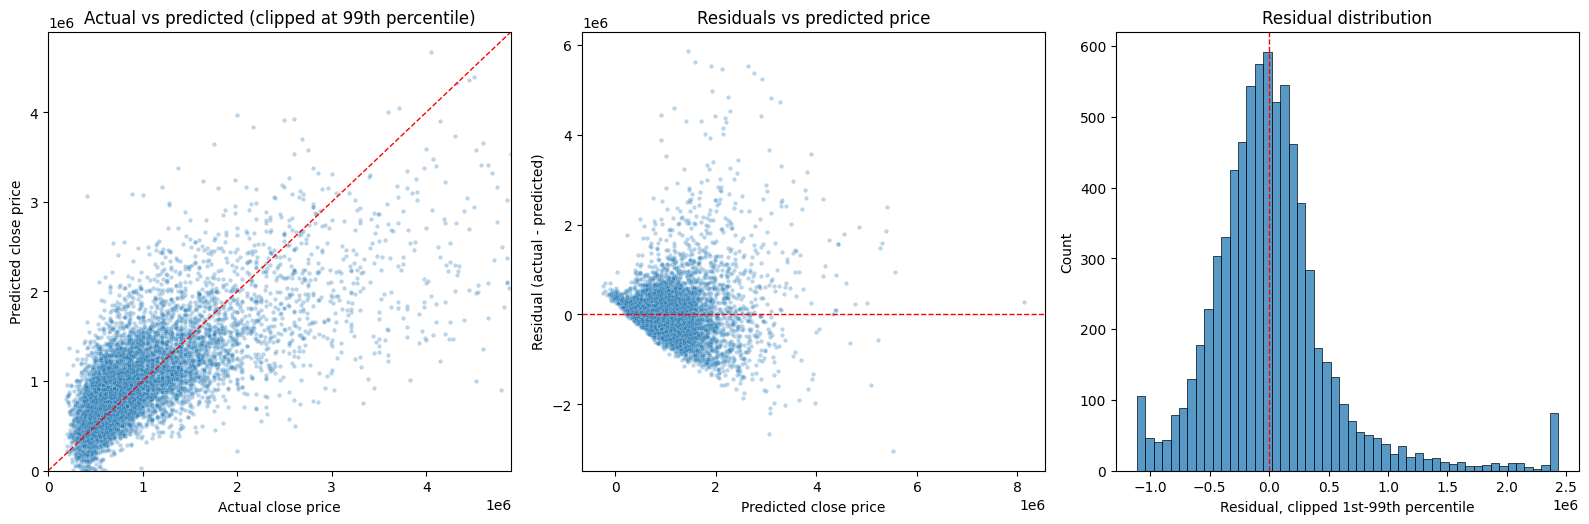

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16 ,5.5))

# Actual vs. Predicted
max_price = np.percentile(y_test, 99)
sns.scatterplot(x=y_test, y=test_pred, s=10, alpha=0.3, ax=axes[0])
axes[0].plot([0, max_price], [0, max_price], color="red", linestyle="--", linewidth=1)
axes[0].set_xlim(0, max_price)
axes[0].set_ylim(0, max_price)
axes[0].set_xlabel("Actual close price")
axes[0].set_ylabel("Predicted close price")
axes[0].set_title("Actual vs predicted (clipped at 99th percentile)")

# Residuals vs. Predicted
residuals = y_test - test_pred
sns.scatterplot(x=test_pred, y=residuals, s=10, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted close price")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals vs predicted price")

# Residual distribution
clipped = residuals.clip(np.quantile(residuals, 0.01), np.quantile(residuals, 0.99))
sns.histplot(clipped, bins=50, ax=axes[2])
axes[2].axvline(0, color="red", linestyle="--", linewidth=1)
axes[2].set_xlabel("Residual, clipped 1st-99th percentile")
axes[2].set_title("Residual distribution")

plt.tight_layout()
plt.show()

In [31]:
# check model performance on train and test sets
def regression_summary(y_true, y_pred, label):
    ape = (np.abs(y_true - y_pred) / y_true) * 100
    return {"split": label, "r2": r2_score(y_true, y_pred),
            "rmse": root_mean_squared_error(y_true, y_pred),
            "mape": ape.mean(), "mdape": np.median(ape)}

summary_df = pd.DataFrame([
    regression_summary(y_train, train_pred2, "train"),
    regression_summary(y_test, test_pred2, "test"),
]).set_index("split").round(4)
display(summary_df.reset_index())

,split,r2,rmse,mape,mdape
0,train,0.8395,336894.6756,19.9247,14.2893
1,test,0.8302,363642.6295,20.5447,14.2088


In [ ]:
# error by price band
error_df = pd.DataFrame({"actual": y_test, "predicted": test_pred})
error_df["abs_pct_error"] = (error_df["actual"] - error_df["predicted"]).abs() / error_df["actual"] * 100
error_df["price_band"] = pd.qcut(error_df["actual"], q=5,
    labels=["Lowest 20%", "Low-mid", "Mid", "Mid-high", "Highest 20%"])

price_band_summary = error_df.groupby("price_band", observed=True).agg(
    n=("actual", "size"),
    mean_actual=("actual", "mean"),
    mape=("abs_pct_error", "mean"),
    mdape=("abs_pct_error", "median"),
).round(2)
display(price_band_summary.reset_index())

,price_band,n,mean_actual,mape,mdape
0,Lowest 20%,1502,427374.06,64.98,51.27
1,Low-mid,1529,650001.57,42.45,31.02
2,Mid,1471,862746.69,30.94,22.83
3,Mid-high,1509,1209905.20,25.57,20.78
4,Highest 20%,1490,2446165.88,28.86,26.22


In [ ]:
# error by MLS area
error_df["MLSAreaMajor"] = test_df["MLSAreaMajor"].values

county_summary = (
    error_df.groupby("MLSAreaMajor", observed=True)
    .agg(n=("actual", "size"), mape=("abs_pct_error", "mean"))
    .query("n >= 30")
    .sort_values("mape", ascending=False)
)
print("Worst-performing counties:"); display(county_summary.head(10))
print("Best-performing counties:"); display(county_summary.tail(10))

Worst-performing counties:


,n,mape
MLSAreaMajor,,
307 - Sun City,32,97.290749
309 - Indio North of East Valley,42,83.333337
263 - Banning/Beaumont/Cherry Valley,98,81.694644
LAC - Lancaster,99,63.552941
APPV - Apple Valley,76,62.194856
BKSF - Bakersfield,49,55.508801
VIC - Victorville,105,54.262916
269 - Yucaipa/Calimesa/Oak Glen,31,53.141655
274 - San Bernardino,67,52.112642


Best-performing counties:


,n,mape
MLSAreaMajor,,
605 - Arcadia,31,24.686470
690 - Upland,36,22.963284
688 - Rancho Cucamonga,58,22.598428
16 - Fountain Valley / Northeast HB,33,21.185191
682 - Chino Hills,37,20.565518
85 - Yorba Linda,41,19.846739
669 - West Covina,39,19.754285
83 - Fullerton,50,18.634731
"75 - Orange, Orange Park Acres E of 55",30,16.741205


In [ ]:
# output model
joblib.dump({
    "X_train": X_train2, "X_test": X_test2,
    "y_train": y_train2, "y_test": y_test2,
    "feature_names": feature_names,
    "encoder": encoder,
    "linear_model": model2,
}, "../data/baseline_artifacts.joblib")

print("Saved feature matrices, encoder, and fitted linear model for reuse in 04_model_comparison.ipynb")

Saved feature matrices, encoder, and fitted linear model for reuse in 04_model_comparison.ipynb
